## Penugasan 5 – Filter Median vs Filter Rata-rata

### Deskripsi
Penugasan ini membandingkan kinerja dua filter dalam mengatasi noise salt-and-pepper:
- **Filter Rata-rata** (Mean & Gaussian): filter linear yang menghitung rata-rata piksel sekitar
- **Filter Median**: filter non-linear yang mengambil nilai median piksel sekitar

Noise ditambahkan menggunakan `util.random_noise` dengan `mode='s&p'` yang mengganti piksel acak dengan nilai 1 (salt) atau 0 (pepper).


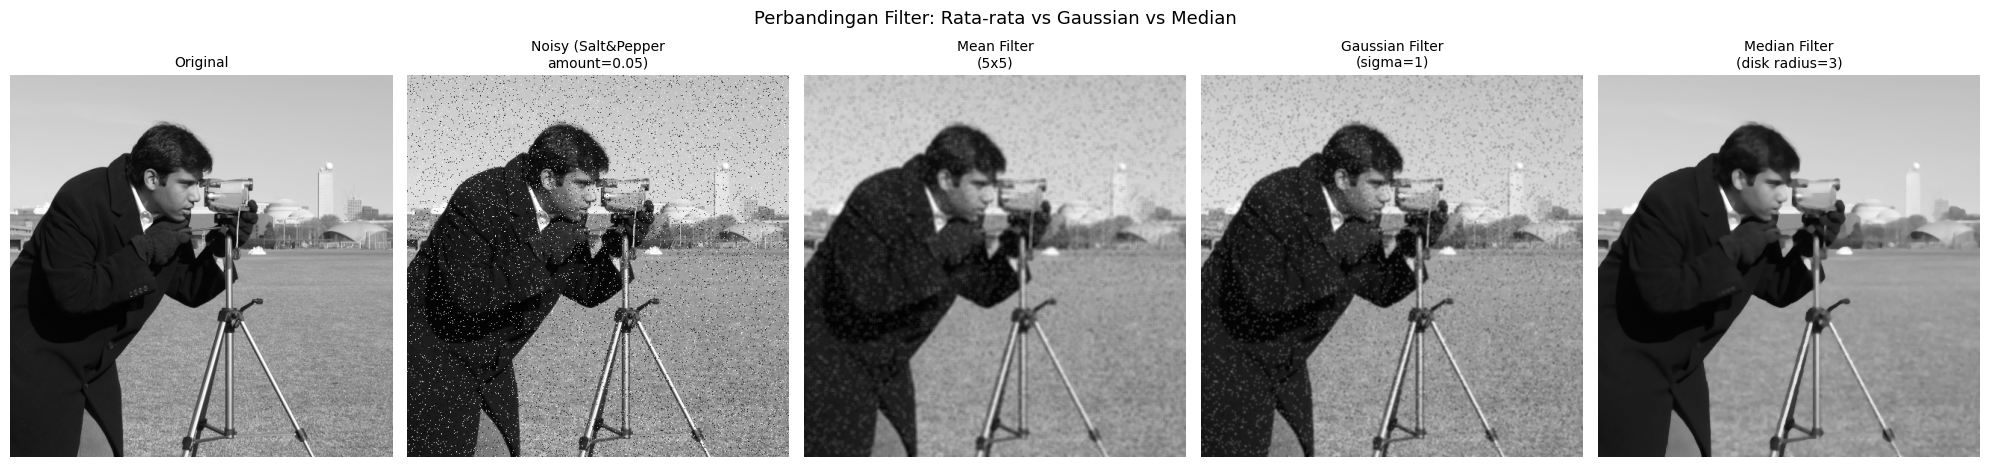

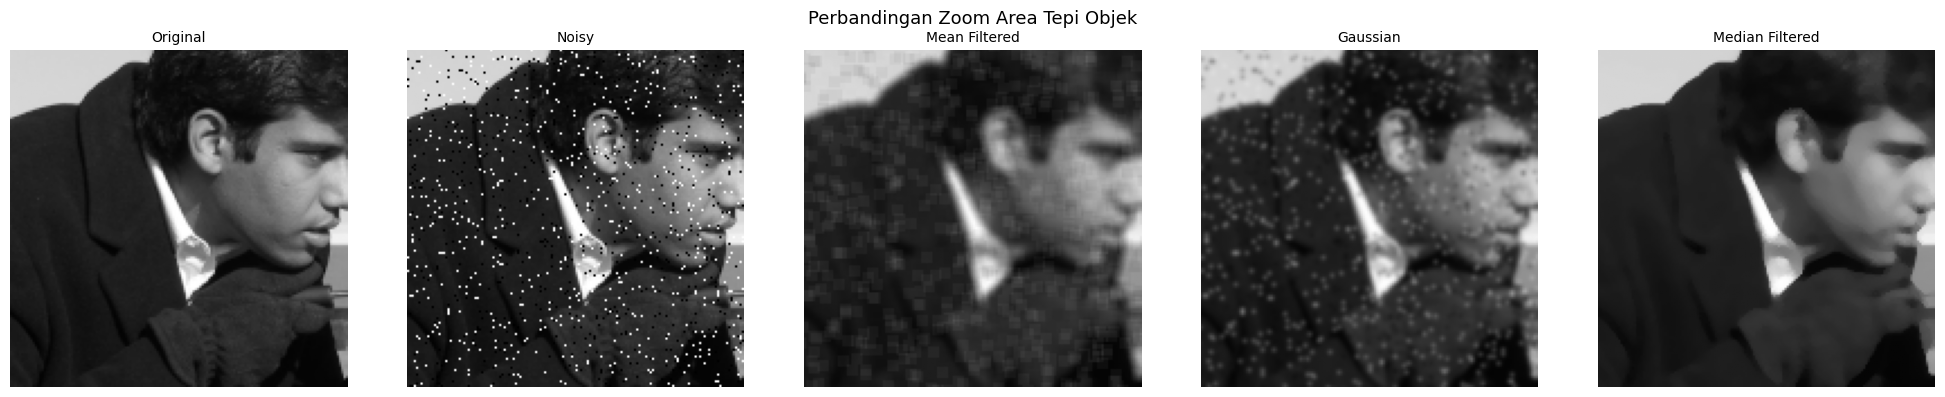

=== Metrik Evaluasi (dibanding citra original) ===
Noisy                | MSE: 0.016528 | PSNR: 17.82 dB
Mean Filtered        | MSE: 0.003046 | PSNR: 25.16 dB
Gaussian Filter      | MSE: 0.002676 | PSNR: 25.73 dB
Median Filtered      | MSE: 0.001705 | PSNR: 27.68 dB


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from scipy import ndimage as ndi
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse

# --------------------------------------------------
# PERSIAPAN CITRA & PENAMBAHAN NOISE
# mode='s&p'   → salt-and-pepper noise
# amount=0.05  → 5% piksel terpengaruh noise
# rng=42       → seed untuk hasil reproducible
# --------------------------------------------------

img_original = img_as_float(data.camera())

img_noisy = util.random_noise(
    img_original,
    mode='s&p',
    amount=0.05,
    rng=42
)

# --------------------------------------------------
# METODE 1: FILTER RATA-RATA (Mean Filter)
# Kernel 5x5 berisi nilai seragam 1/25
# --------------------------------------------------

kernel_size = 5
kernel_mean = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size ** 2)
img_mean_filtered = ndi.convolve(img_noisy, kernel_mean, mode='reflect')

# --------------------------------------------------
# METODE 2: FILTER GAUSSIAN
# sigma=1 → standar deviasi kernel Gaussian
# --------------------------------------------------

img_gaussian_filtered = filters.gaussian(img_noisy, sigma=1)

# --------------------------------------------------
# METODE 3: FILTER MEDIAN
# disk(3) → structuring element lingkaran radius 3
# --------------------------------------------------

disk3 = morphology.disk(3)
img_median_filtered = filters.median(img_noisy, disk3)

# --------------------------------------------------
# PLOTTING: PERBANDINGAN VISUAL (baris 1)
# --------------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Perbandingan Filter: Rata-rata vs Gaussian vs Median", fontsize=13)

titles = [
    "Original",
    "Noisy (Salt&Pepper\namount=0.05)",
    f"Mean Filter\n({kernel_size}x{kernel_size})",
    "Gaussian Filter\n(sigma=1)",
    "Median Filter\n(disk radius=3)"
]
images = [img_original, img_noisy, img_mean_filtered, img_gaussian_filtered, img_median_filtered]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# PLOTTING: CROP AREA TEPI OBJEK (zoom in)
# Fokus pada area tepi untuk melihat perbedaan ketajaman
# --------------------------------------------------

row, col = 100, 100
size = 150

crops = {
    "Original"      : img_original[row:row+size, col:col+size],
    "Noisy"         : img_noisy[row:row+size, col:col+size],
    "Mean Filtered" : img_mean_filtered[row:row+size, col:col+size],
    "Gaussian"      : img_gaussian_filtered[row:row+size, col:col+size],
    "Median Filtered": img_median_filtered[row:row+size, col:col+size],
}

fig2, axes2 = plt.subplots(1, 5, figsize=(20, 4))
fig2.suptitle("Perbandingan Zoom Area Tepi Objek", fontsize=13)

for ax, (title, crop) in zip(axes2, crops.items()):
    ax.imshow(crop, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# METRIK EVALUASI: MSE & PSNR
# --------------------------------------------------

print("=== Metrik Evaluasi (dibanding citra original) ===")
results = {
    "Noisy"           : img_noisy,
    "Mean Filtered"   : img_mean_filtered,
    "Gaussian Filter" : img_gaussian_filtered,
    "Median Filtered" : img_median_filtered,
}

for name, img in results.items():
    mse_val  = mse(img_original, img)
    psnr_val = psnr(img_original, img, data_range=1.0)
    print(f"{name:<20} | MSE: {mse_val:.6f} | PSNR: {psnr_val:.2f} dB")

### Kesimpulan
Filter median unggul secara signifikan dibanding filter rata-rata maupun Gaussian dalam mengatasi noise salt-and-pepper. Hal ini karena noise salt-and-pepper bersifat impulsif — hanya sebagian kecil piksel yang terkena nilai ekstrem (0 atau 1). Filter median sebagai filter non-linear mengambil nilai tengah dari seluruh piksel di sekitar suatu titik, sehingga nilai ekstrem outlier otomatis tersingkir tanpa memengaruhi hasil. Tepi objek pun tetap tajam karena median tidak mencampur nilai melintasi batas tepi seperti halnya rata-rata.

Sebaliknya, filter rata-rata dan Gaussian menyertakan nilai piksel noise (0 atau 1) ke dalam perhitungan rata-rata, sehingga noise tidak sepenuhnya hilang melainkan hanya tersebar ke piksel sekitarnya. Akibatnya tepi objek menjadi kabur dan beberapa sisa noise masih terlihat. Nilai PSNR yang lebih tinggi dan MSE yang lebih rendah pada hasil filter median mengonfirmasi keunggulan kuantitatifnya untuk kasus noise impuls.